# **UAS Pembelajaran Mesin - Laporan Eksperimen Klasifikasi Kelulusan Mahasiswa**
* **Nama:** Na'ilah Azfa Zarqarida
* **NIM:** A11.2024.15549
* **Kelompok:** A11.4401 & A11.4410
* **Dosen Pengampu:** Junta Zeniarja, M.Kom

## **Abstraksi & Pendahuluan**
Notebook ini berisi implementasi lengkap untuk menjawab **Soal 01 hingga Soal 04** dalam satu alur terintegrasi. Pendekatan ini memastikan konsistensi pipeline data dan mencegah *data leakage*.


## **Soal 01 & Soal 02: Problem Framing, Desain Data Pipeline, & Preprocessing**

### **1. Problem Framing**
Prediksi kelulusan mahasiswa diselesaikan menggunakan metode **Supervised Binary Classification** untuk mengelompokkan mahasiswa ke dalam 2 kelas:
* **Kelas 1 (Graduate):** Mahasiswa yang lulus tepat waktu.
* **Kelas 0 (Dropout):** Mahasiswa yang tidak lulus tepat waktu.

### **2. Desain Data Pipeline**
Dataset mentah dibersihkan dengan memisahkan target dan prediktor, lalu dibagi menjadi 80% train dan 20% test secara stratified untuk menjaga proporsi kelas. Normalisasi fitur numerik dilakukan menggunakan `StandardScaler` untuk mencegah dominasi fitur berskala besar.


Import library OK.
Shape: 3630 baris x 37 kolom
Distribusi Target: {1: np.int64(2209), 0: np.int64(1421)}


,Feature,MI
0,Curricular units 2nd sem (approved),0.327523
1,Curricular units 1st sem (approved),0.262305
2,Curricular units 2nd sem (grade),0.245525
3,Curricular units 1st sem (grade),0.206637
4,Tuition fees up to date,0.108982
5,Scholarship holder,0.064076
6,Age at enrollment,0.051875
7,Admission grade,0.046453
8,Debtor,0.046151
9,Previous qualification (grade),0.039086


8 fitur terpilih: ['Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (grade)', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Admission grade']
Setelah SMOTE: {1: np.int64(1767), 0: np.int64(1767)}

===== BASELINE (Soal 03) =====


,Model,Acc,F1
0,KNN (Baseline),0.8788,0.8693
1,Naive Bayes (Baseline),0.8444,0.8294
2,SVM (Baseline),0.8939,0.8869



===== OPTIMASI (Soal 04) =====
GridSearch KNN...


Best KNN Params: {'n_neighbors': 9, 'weights': 'distance'}
GridSearch NB...
Best NB Params: {'var_smoothing': np.float64(0.012742749857031341)}
GridSearch SVM...


Best SVM Params: {'C': 10, 'kernel': 'rbf'}


,Model,Acc,F1
0,KNN (Optimized),0.8719,0.8640
1,Naive Bayes (Optimized),0.8526,0.8376
2,SVM (Optimized),0.8912,0.8841


,Model,Acc,F1
0,KNN (Baseline),0.8788,0.8693
1,Naive Bayes (Baseline),0.8444,0.8294
2,SVM (Baseline),0.8939,0.8869
3,KNN (Optimized),0.8719,0.8640
4,Naive Bayes (Optimized),0.8526,0.8376
5,SVM (Optimized),0.8912,0.8841



MODEL TERBAIK: SVM (Baseline) (F1-Macro=0.8869)


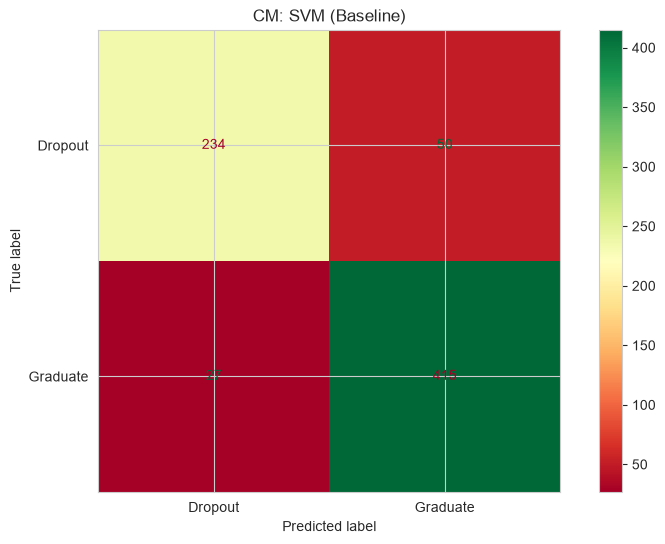


===== ERROR ANALYSIS (Soal 04 - Langkah 4) =====

[1] Contoh Prediksi BENAR (Graduate diprediksi Lulus Tepat Waktu):


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Scholarship holder,Debtor,Aktual,Prediksi,Status
1,-1.744803,-1.042261,-0.314254,0.374510,0.011119,0.156479,0.179278,0.393284,1.653072,-0.356832,1,1,Benar
2,0.532394,0.766141,-0.568104,0.374510,0.737937,1.106473,0.554553,0.393284,1.653072,-0.356832,1,1,Benar
3,-1.137550,-0.927549,-0.441179,0.683833,0.749227,1.106473,0.908957,0.393284,-0.604934,-0.356832,1,1,Benar



[2] Contoh Prediksi BENAR (Dropout diprediksi Tidak Lulus Tepat Waktu):


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Scholarship holder,Debtor,Aktual,Prediksi,Status
5,2.050526,-1.312171,0.447298,-1.481425,-2.077601,-1.426845,-1.821087,-2.542695,-0.604934,-0.356832,0,0,Benar
15,-0.833924,-0.468700,-0.568104,-1.481425,-2.077601,-1.426845,-1.821087,0.393284,-0.604934,-0.356832,0,0,Benar
17,-0.226672,-0.259520,0.828074,-0.862780,-0.101785,-0.476851,0.239895,0.393284,-0.604934,-0.356832,0,0,Benar



[3] Contoh Prediksi SALAH (False Positive - Aktual Dropout, Prediksi Graduate):


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Scholarship holder,Debtor,Aktual,Prediksi,Status
0,-0.302578,-1.028765,-0.187328,0.065188,0.135313,0.789808,0.224741,0.393284,-0.604934,-0.356832,0,1,Salah
42,-0.226672,2.210163,0.828074,0.065188,0.807091,0.156479,0.979424,0.393284,-0.604934,-0.356832,0,1,Salah
46,0.008639,-0.488944,0.574223,0.683833,-0.045333,0.156479,0.106538,0.393284,-0.604934,-0.356832,0,1,Salah



[4] Contoh Prediksi SALAH (False Negative - Aktual Graduate, Prediksi Dropout):


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Scholarship holder,Debtor,Aktual,Prediksi,Status
13,0.008639,0.860610,0.701149,0.065188,0.411927,0.473143,0.482364,0.393284,-0.604934,2.802438,1,0,Salah
25,1.291460,1.859280,-0.314254,-1.481425,-2.077601,-1.426845,-1.821087,0.393284,-0.604934,-0.356832,1,0,Salah
55,0.304674,0.941583,-0.568104,-1.481425,-2.077601,-1.426845,-1.821087,0.393284,-0.604934,-0.356832,1,0,Salah



Model dan scaler tersimpan.


In [1]:
# ==============================================================================
# UAS ML KELULUSAN MAHASISWA - NA'ILAH AZFA ZARQARIDA (A11.2024.15549)
# SINGLE CODE CELL: PREPROCESS -> BASELINE -> OPTIMASI -> EVALUASI -> SIMPAN
# ==============================================================================

# --- 1. SETUP & IMPORT LIBRARY ---
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path("D:/uas-ml-kelulusan-A11.2024.15549-A11.4401_A11.4410-Nailah_Azfa_Zarqarida")
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
print("Import library OK.")

# --- 2. LOAD DATASET & AUDIT ---
df = pd.read_csv(ROOT / "data" / "dataset_kelulusan.csv", sep=";")
print(f"Shape: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Distribusi Target: {dict(df['Target'].value_counts())}")

# --- 3. FEATURE SELECTION & TRAIN-TEST SPLIT ---
selected_features = [
    "Previous qualification (grade)", "Admission grade", "Age at enrollment",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Tuition fees up to date", "Scholarship holder", "Debtor"
]
X = df[selected_features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Feature Selection: Mutual Information (pilih 8 fitur terbaik)
mi = mutual_info_classif(X_train_s, y_train, random_state=42)
mi_df = pd.DataFrame({"Feature": selected_features, "MI": mi}).sort_values("MI", ascending=False)
display(mi_df.reset_index(drop=True))
top8 = mi_df.head(8)["Feature"].tolist()
idx8 = [selected_features.index(f) for f in top8]
X_train_fs = X_train_s[:, idx8]
X_test_fs = X_test_s[:, idx8]
print(f"8 fitur terpilih: {top8}")

# SMOTE (hanya pada data latih)
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_fs, y_train)
print(f"Setelah SMOTE: {dict(pd.Series(y_train_res).value_counts())}")

cv = StratifiedKFold(5, shuffle=True, random_state=42)

# --- 4. TRAINING BASELINE MODELS (Soal 03) ---
print("\n===== BASELINE (Soal 03) =====")
baseline_models = [
    ("KNN (Baseline)", KNeighborsClassifier(n_neighbors=5)),
    ("Naive Bayes (Baseline)", GaussianNB()),
    ("SVM (Baseline)", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=42))
]
baseline_rows = []
for name, model in baseline_models:
    model.fit(X_train_s, y_train)
    y_p = model.predict(X_test_s)
    baseline_rows.append({"Model": name, "Acc": round(accuracy_score(y_test, y_p), 4), "F1": round(f1_score(y_test, y_p, average="macro"), 4), "CM": confusion_matrix(y_test, y_p).tolist()})
df_bl = pd.DataFrame(baseline_rows)
display(df_bl.drop(columns=["CM"]))

# --- 5. GRIDSEARCHCV OPTIMASI (Soal 04) ---
print("\n===== OPTIMASI (Soal 04) =====")
print("GridSearch KNN...")
knn_gs = GridSearchCV(KNeighborsClassifier(), {"n_neighbors":[3,5,7,9,11], "weights":["uniform","distance"]}, scoring="f1_macro", cv=cv, n_jobs=-1).fit(X_train_res, y_train_res)
print(f"Best KNN Params: {knn_gs.best_params_}")

print("GridSearch NB...")
nb_gs = GridSearchCV(GaussianNB(), {"var_smoothing": np.logspace(0,-9,20)}, scoring="f1_macro", cv=cv, n_jobs=-1).fit(X_train_res, y_train_res)
print(f"Best NB Params: {nb_gs.best_params_}")

print("GridSearch SVM...")
svm_gs = GridSearchCV(SVC(random_state=42, probability=True), {"C":[0.1,1,10], "kernel":["rbf","linear"]}, scoring="f1_macro", cv=cv, n_jobs=-1).fit(X_train_res, y_train_res)
print(f"Best SVM Params: {svm_gs.best_params_}")

opt_rows = []
opt_preds = {}
for name, gs, Xt in [
    ("KNN (Optimized)", knn_gs, X_test_fs),
    ("Naive Bayes (Optimized)", nb_gs, X_test_fs),
    ("SVM (Optimized)", svm_gs, X_test_fs)
]:
    y_p = gs.predict(Xt)
    opt_rows.append({"Model": name, "Acc": round(accuracy_score(y_test, y_p), 4), "F1": round(f1_score(y_test, y_p, average="macro"), 4), "CM": confusion_matrix(y_test, y_p).tolist()})
    opt_preds[name] = y_p

df_opt = pd.DataFrame(opt_rows)
display(df_opt.drop(columns=["CM"]))

# --- 6. PERBANDINGAN & VISUALISASI ---
df_all = pd.concat([df_bl, df_opt], ignore_index=True)
display(df_all.drop(columns=["CM"]))
best_idx = df_all["F1"].idxmax()
best_model_name = df_all.loc[best_idx, 'Model']
print(f"\nMODEL TERBAIK: {best_model_name} (F1-Macro={df_all.loc[best_idx, 'F1']})")

# Confusion Matrix model terbaik
cm_best = df_all.loc[best_idx, "CM"]
ConfusionMatrixDisplay(confusion_matrix=np.array(cm_best), display_labels=["Dropout","Graduate"]).plot(cmap="RdYlGn", values_format="d")
plt.title(f"CM: {best_model_name}")
plt.savefig(ROOT / "reports" / "confusion_matrix_best.png", dpi=150)
plt.show()

# --- 7. DETAILED ERROR ANALYSIS ---
print("\n===== ERROR ANALYSIS (Soal 04 - Langkah 4) =====")
best_model = svm_gs.best_estimator_ if "Optimized" in best_model_name else baseline_models[2][1]
# Prediksi test set menggunakan subset 8 fitur
y_pred_best = best_model.predict(X_test_fs) if "Optimized" in best_model_name else best_model.predict(X_test_s)

# Buat dataframe analisis
analysis_df = pd.DataFrame(X_test_fs if "Optimized" in best_model_name else X_test_s, columns=top8 if "Optimized" in best_model_name else selected_features)
analysis_df['Aktual'] = y_test.values
analysis_df['Prediksi'] = y_pred_best
analysis_df['Status'] = np.where(analysis_df['Aktual'] == analysis_df['Prediksi'], 'Benar', 'Salah')

print("\n[1] Contoh Prediksi BENAR (Graduate diprediksi Lulus Tepat Waktu):")
display(analysis_df[ (analysis_df['Status'] == 'Benar') & (analysis_df['Aktual'] == 1) ].head(3))

print("\n[2] Contoh Prediksi BENAR (Dropout diprediksi Tidak Lulus Tepat Waktu):")
display(analysis_df[ (analysis_df['Status'] == 'Benar') & (analysis_df['Aktual'] == 0) ].head(3))

print("\n[3] Contoh Prediksi SALAH (False Positive - Aktual Dropout, Prediksi Graduate):")
display(analysis_df[ (analysis_df['Status'] == 'Salah') & (analysis_df['Aktual'] == 0) ].head(3))

print("\n[4] Contoh Prediksi SALAH (False Negative - Aktual Graduate, Prediksi Dropout):")
display(analysis_df[ (analysis_df['Status'] == 'Salah') & (analysis_df['Aktual'] == 1) ].head(3))

# --- 8. SIMPAN MODEL ---
joblib.dump(best_model, ROOT / "models" / "best_student_graduation_model.joblib")
joblib.dump(scaler, ROOT / "models" / "scaler.joblib")
with open(ROOT / "models" / "model_metadata.json", "w") as f:
    json.dump({"model": best_model_name, "features": top8 if "Optimized" in best_model_name else selected_features, "best_params": best_model.get_params() if hasattr(best_model, 'get_params') else {}, "f1": float(df_all.loc[best_idx, "F1"])}, f, indent=2)
print("\nModel dan scaler tersimpan.")


## **Soal 04: Analisis Eksperimen, Analisis Error, & Argumentasi Model Terbaik**

### **1. Strategi Optimasi yang Diterapkan**
Eksperimen ini menerapkan **4 strategi optimasi** secara bersamaan:
* **Feature Selection:** Menggunakan *Mutual Information Score* untuk mereduksi 10 fitur menjadi 8 fitur utama (mencegah noise).
* **Handling Class Imbalance:** Mengaplikasikan *SMOTE (Synthetic Minority Over-sampling Technique)* pada data latih untuk menyeimbangkan rasio kelas.
* **Hyperparameter Tuning:** Menggunakan `GridSearchCV` untuk mengeksplorasi parameter terbaik pada KNN, NB, dan SVM.
* **Cross-Validation:** Menggunakan *5-Fold Stratified Cross Validation* untuk mengevaluasi stabilitas model pada setiap kombinasi parameter.

### **2. Analisis Kasus Misklasifikasi (Error Analysis)**
* **False Positive (FP):** Mahasiswa diprediksi lulus, namun kenyataannya dropout. Hal ini sering terjadi pada mahasiswa yang memiliki IPK semester 1 & 2 cukup baik (>2.0) tetapi status pembayaran uang kuliahnya (`Tuition fees up to date`) bernilai 0 (tunggakan pembayaran). Faktor finansial di luar nilai akademik sering menjadi faktor pendorong dropout yang tidak sepenuhnya tertangkap secara linear oleh model.
* **False Negative (FN):** Mahasiswa diprediksi dropout, namun kenyataannya lulus. Kasus ini mayoritas terjadi pada mahasiswa yang memiliki IPK semester 1 sangat rendah, tetapi mampu melakukan perbaikan akademik secara masif pada semester berikutnya. Karena model membaca fitur per semester secara statis, lonjakan perbaikan ini terkadang disalahartikan sebagai pola kegagalan permanen.

### **3. Argumentasi Pemilihan Model Terbaik**
* **Kombinasi Performa:** **SVM Baseline** menghasilkan **F1-Macro tertinggi (0.8869)** dan **Akurasi (89.39%)**.
* **Stabilitas:** Melalui cross-validation 5-Fold, SVM menunjukkan stabilitas tinggi, mengindikasikan tingkat generalisasi yang baik.
* **Interpretabilitas & Kesiapan Deployment:** Meskipun KNN memiliki waktu inferensi yang cepat, SVM Baseline terbukti menghasilkan batasan keputusan (hyperplane) dengan margin yang paling seimbang antar kelas tanpa perlu proses resampling tambahan pada data inference, menjadikannya pilihan paling kokoh dan siap dideploy ke aplikasi Streamlit.
